# 38 - Gemma calibrated semantic-event hybrid

**Question.** Can the leading Gemma-timing/FinBERT-ranking construction be
translated from calibration-fragile exact probability endpoints to a
return-independent, semantically calibrated high-conviction event rule?

The threshold is chosen **without LSEG returns**. The frozen 1,000-row public
validation sample is sorted by sentence SHA-256 and split 700/300. On the first
700 rows, test only the fixed directional-probability grid
`{0.50, 0.55, ..., 0.95}` and select the lowest threshold with at least 20
positive and 20 negative predictions and a 95% Wilson precision lower bound
of at least 0.75 for both directions. The untouched 300-row audit must retain
at least 10 predictions and empirical precision of at least 0.75 per side.
If that gate fails, the notebook stops before LSEG returns.

A high-conviction event requires positive or negative to be the unique
probability argmax and its probability to exceed the public-label threshold.
All other headlines become neutral. At firm-open grain, a company is positive
or negative only when the strongest high-conviction direction is unopposed;
opposing directions tie and abstain. Gemma supplies event dates and counts;
the unchanged complete FinBERT strongest-event score ranks names. The
immutable original 33, 25% name cap, one-session horizon, cash on inactive
dates, drift-aware ledger, final liquidation, and 10 bps/side remain fixed.

The **retrospective strategy gate** requires the public calibration gate,
at least 60 active sessions, cash-relative five-session block interval above
zero with p<0.05, exact all-shift timing p<0.05, break-even above cost, and
nonnegative independently initialized half-sample Sharpes. The separate
factor-alpha gate requires the HAC(5) market-plus-sector-spread intercept to
exclude zero. Company and sector exclusions are quality checks. Because
Notebooks 13 and 29-37 already opened these returns, even a pass remains
hypothesis-generating and cannot be called validation.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.lseg_expanded import (  # noqa: E402
    build_expanded_aggregation_panel,
    load_price_exports,
    load_success_scores,
    map_headlines_to_entry_sessions,
)
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260812
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0
CALIBRATION_ROWS = 700
MIN_CALIBRATION_PER_SIDE = 20
MIN_AUDIT_PER_SIDE = 10
CALIBRATION_WILSON_FLOOR = 0.75
AUDIT_PRECISION_FLOOR = 0.75
THRESHOLD_GRID = tuple(round(value, 2) for value in np.arange(0.50, 0.951, 0.05))

VALIDATION_DIR = (
    REPO_ROOT
    / "final_experiments/outputs/12_lseg_44_labelling/openrouter_gemma4_validation"
)
VALIDATION_RESPONSES = VALIDATION_DIR / "responses.jsonl"
VALIDATION_MANIFEST = VALIDATION_DIR / "manifest.json"
COLLECTION_DIR = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_PATH = (
    COLLECTION_DIR
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
FINBERT_PANEL_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
ENDPOINT_PANEL_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
NOTEBOOK36_DIR = (
    REPO_ROOT / "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit"
)
NOTEBOOK36_MANIFEST = NOTEBOOK36_DIR / "manifest.json"
NOTEBOOK36_DAILY = NOTEBOOK36_DIR / "capped_hybrid_daily.parquet"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/38_gemma_calibrated_semantic_event_hybrid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Public-label-only threshold calibration

In [2]:
validation_manifest = json.loads(VALIDATION_MANIFEST.read_text())
if validation_manifest["status"] != "completed":
    raise ValueError("public validation manifest is not complete")
if validation_manifest["input"]["licensed_lseg_text"]:
    raise ValueError("calibration input must not contain LSEG text")

response_rows = [
    json.loads(line)
    for line in VALIDATION_RESPONSES.open(encoding="utf-8")
    if line.strip()
]
responses = pd.DataFrame(response_rows)
responses = responses.loc[
    responses["status"].eq("success") & responses["parse_status"].eq("valid")
].copy()
responses = (
    responses.sort_values(["sentence_sha256", "attempt_count"], kind="mergesort")
    .drop_duplicates("sentence_sha256", keep="last")
    .sort_values("sentence_sha256", kind="mergesort")
    .reset_index(drop=True)
)
if len(responses) != 1_000:
    raise ValueError("expected 1,000 unique successful public validation rows")
for label in ("positive", "negative", "neutral"):
    responses[f"p_{label}"] = responses["probabilities"].map(
        lambda value, key=label: float(value[key])
    )
if not np.isclose(
    responses[["p_positive", "p_negative", "p_neutral"]].sum(axis=1),
    1.0,
    atol=1e-6,
).all():
    raise ValueError("public validation probabilities do not sum to one")


def wilson_lower(successes: int, total: int) -> float:
    if total <= 0:
        return float("nan")
    z = 1.959963984540054
    proportion = successes / total
    denominator = 1.0 + z**2 / total
    centre = proportion + z**2 / (2.0 * total)
    radius = z * math.sqrt(
        proportion * (1.0 - proportion) / total + z**2 / (4.0 * total**2)
    )
    return float((centre - radius) / denominator)


def directional_selection(frame: pd.DataFrame, direction: str, threshold: float) -> pd.Series:
    others = [label for label in ("positive", "negative", "neutral") if label != direction]
    return frame[f"p_{direction}"].ge(threshold) & frame[f"p_{direction}"].gt(
        frame[[f"p_{label}" for label in others]].max(axis=1)
    )


calibration = responses.iloc[:CALIBRATION_ROWS].copy()
audit = responses.iloc[CALIBRATION_ROWS:].copy()
calibration_rows = []
for threshold in THRESHOLD_GRID:
    row: dict[str, float | int] = {"threshold": threshold}
    for split_name, frame in (("calibration", calibration), ("audit", audit)):
        for direction in ("positive", "negative"):
            selected = directional_selection(frame, direction, threshold)
            total = int(selected.sum())
            successes = int(frame.loc[selected, "true_label"].eq(direction).sum())
            row[f"{split_name}_{direction}_n"] = total
            row[f"{split_name}_{direction}_precision"] = (
                successes / total if total else float("nan")
            )
            row[f"{split_name}_{direction}_wilson_low"] = wilson_lower(
                successes, total
            )
    calibration_rows.append(row)
calibration_table = pd.DataFrame(calibration_rows)
eligible_thresholds = calibration_table.loc[
    calibration_table["calibration_positive_n"].ge(MIN_CALIBRATION_PER_SIDE)
    & calibration_table["calibration_negative_n"].ge(MIN_CALIBRATION_PER_SIDE)
    & calibration_table["calibration_positive_wilson_low"].ge(
        CALIBRATION_WILSON_FLOOR
    )
    & calibration_table["calibration_negative_wilson_low"].ge(
        CALIBRATION_WILSON_FLOOR
    )
].copy()
if eligible_thresholds.empty:
    raise RuntimeError("no public-label threshold clears the calibration gate")
selected_threshold = float(eligible_thresholds.iloc[0]["threshold"])
selected_calibration = calibration_table.set_index("threshold").loc[selected_threshold]
public_calibration_gate = bool(
    selected_calibration["audit_positive_n"] >= MIN_AUDIT_PER_SIDE
    and selected_calibration["audit_negative_n"] >= MIN_AUDIT_PER_SIDE
    and selected_calibration["audit_positive_precision"] >= AUDIT_PRECISION_FLOOR
    and selected_calibration["audit_negative_precision"] >= AUDIT_PRECISION_FLOOR
)
calibration_summary = pd.DataFrame(
    [
        {
            "selected_threshold": selected_threshold,
            "calibration_positive_n": int(
                selected_calibration["calibration_positive_n"]
            ),
            "calibration_positive_precision": float(
                selected_calibration["calibration_positive_precision"]
            ),
            "calibration_positive_wilson_low": float(
                selected_calibration["calibration_positive_wilson_low"]
            ),
            "calibration_negative_n": int(
                selected_calibration["calibration_negative_n"]
            ),
            "calibration_negative_precision": float(
                selected_calibration["calibration_negative_precision"]
            ),
            "calibration_negative_wilson_low": float(
                selected_calibration["calibration_negative_wilson_low"]
            ),
            "audit_positive_n": int(selected_calibration["audit_positive_n"]),
            "audit_positive_precision": float(
                selected_calibration["audit_positive_precision"]
            ),
            "audit_negative_n": int(selected_calibration["audit_negative_n"]),
            "audit_negative_precision": float(
                selected_calibration["audit_negative_precision"]
            ),
            "public_calibration_gate": public_calibration_gate,
        }
    ]
)
display(calibration_table)
display(calibration_summary.T)
if not public_calibration_gate:
    raise RuntimeError("public audit gate failed; LSEG return stage is forbidden")

,threshold,calibration_positive_n,calibration_positive_precision,calibration_positive_wilson_low,calibration_negative_n,calibration_negative_precision,calibration_negative_wilson_low,audit_positive_n,audit_positive_precision,audit_positive_wilson_low,audit_negative_n,audit_negative_precision,audit_negative_wilson_low
0,0.500000,232,0.806034,0.750341,121,0.818182,0.740029,106,0.735849,0.644740,57,0.789474,0.667139
1,0.550000,232,0.806034,0.750341,121,0.818182,0.740029,106,0.735849,0.644740,57,0.789474,0.667139
2,0.600000,232,0.806034,0.750341,121,0.818182,0.740029,106,0.735849,0.644740,56,0.803571,0.681554
3,0.650000,163,0.920245,0.868338,112,0.857143,0.780486,70,0.828571,0.723834,53,0.830189,0.707747
4,0.700000,162,0.919753,0.867555,104,0.884615,0.809080,68,0.838235,0.733100,48,0.875000,0.752995
5,0.750000,118,0.983051,0.940303,97,0.907216,0.832991,56,0.910714,0.807440,45,0.888889,0.765009
6,0.800000,113,0.982301,0.937755,88,0.920455,0.844801,51,0.921569,0.815001,37,0.918919,0.786993
7,0.850000,101,0.980198,0.930654,83,0.927711,0.851132,48,0.916667,0.804467,36,0.944444,0.818553
8,0.900000,48,1.000000,0.925900,32,0.937500,0.798529,25,1.000000,0.866808,16,0.875000,0.639772
9,0.950000,41,1.000000,0.914332,17,1.000000,0.815682,18,1.000000,0.824121,7,1.000000,0.645670


,0
selected_threshold,0.650000
calibration_positive_n,163
calibration_positive_precision,0.920245
calibration_positive_wilson_low,0.868338
calibration_negative_n,112
calibration_negative_precision,0.857143
calibration_negative_wilson_low,0.780486
audit_positive_n,70
audit_positive_precision,0.828571
audit_negative_n,53


## Frozen high-conviction LSEG event schedule

No LSEG headline text is loaded. Successful probabilities and canonical
metadata come from the complete, hash-validated 26B checkpoint.

In [3]:
gemma_scores, gemma_input_audit = load_success_scores(GEMMA_PATH, scorer="gemma4_26b")
positive_event = gemma_scores["p_positive"].ge(selected_threshold) & gemma_scores[
    "p_positive"
].gt(gemma_scores[["p_negative", "p_neutral"]].max(axis=1))
negative_event = gemma_scores["p_negative"].ge(selected_threshold) & gemma_scores[
    "p_negative"
].gt(gemma_scores[["p_positive", "p_neutral"]].max(axis=1))
if (positive_event & negative_event).any():
    raise RuntimeError("directional event masks overlap")
semantic_scores = gemma_scores.copy()
semantic_scores["label"] = np.select(
    [positive_event, negative_event], ["positive", "negative"], default="neutral"
)
semantic_scores["score"] = np.select(
    [positive_event, negative_event], [1.0, -1.0], default=0.0
)
semantic_scores["scorer"] = "gemma4_26b_public_calibrated_direction"

prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)
semantic_events = map_headlines_to_entry_sessions(semantic_scores, prices)
semantic_panel_all = build_expanded_aggregation_panel(semantic_events, prices)
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
original_set = set(original_symbols)
direction_presence = (
    semantic_events.loc[semantic_events["symbol"].isin(original_set)]
    .assign(
        has_positive=lambda frame: frame["score"].eq(1.0),
        has_negative=lambda frame: frame["score"].eq(-1.0),
    )
    .groupby(["entry_session", "symbol"], sort=True)[
        ["has_positive", "has_negative"]
    ]
    .max()
    .reset_index()
)
positive_only_firm_opens = int(
    (direction_presence["has_positive"] & ~direction_presence["has_negative"]).sum()
)
negative_only_firm_opens = int(
    (~direction_presence["has_positive"] & direction_presence["has_negative"]).sum()
)
opposing_direction_firm_opens = int(
    (direction_presence["has_positive"] & direction_presence["has_negative"]).sum()
)
any_direction_firm_opens = (
    positive_only_firm_opens
    + negative_only_firm_opens
    + opposing_direction_firm_opens
)
semantic_panel = semantic_panel_all.loc[
    semantic_panel_all["symbol"].isin(original_set)
].copy()
semantic_panel["session_date"] = pd.to_datetime(
    semantic_panel["session_date"]
).dt.normalize()
semantic_panel = semantic_panel.sort_values(
    ["session_date", "symbol"], kind="mergesort"
).reset_index(drop=True)
if len(semantic_panel) != 167 * 33:
    raise ValueError("semantic event panel is not the expected 167 x 33 rectangle")
if not semantic_panel.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("semantic event panel is incomplete")

_, semantic_target_audit = build_exact_extrema_targets(
    semantic_panel, single_name_cap=SINGLE_NAME_CAP
)
endpoint_panel = pd.read_parquet(ENDPOINT_PANEL_PATH)
endpoint_panel["session_date"] = pd.to_datetime(endpoint_panel["session_date"]).dt.normalize()
endpoint_panel = endpoint_panel.loc[endpoint_panel["symbol"].isin(original_set)].copy()
_, endpoint_target_audit = build_exact_extrema_targets(
    endpoint_panel, single_name_cap=SINGLE_NAME_CAP
)

semantic_eligible = set(
    semantic_target_audit.loc[semantic_target_audit["eligible"], "session_date"]
)
endpoint_eligible = set(
    endpoint_target_audit.loc[endpoint_target_audit["eligible"], "session_date"]
)
schedule_union = semantic_eligible | endpoint_eligible
schedule_comparison = pd.DataFrame(
    [
        {
            "selected_threshold": selected_threshold,
            "total_headlines": len(semantic_scores),
            "high_positive_headlines": int(positive_event.sum()),
            "high_negative_headlines": int(negative_event.sum()),
            "semantic_positive_firm_opens": int(
                np.isclose(semantic_panel["strongest_event"], 1.0).sum()
            ),
            "semantic_negative_firm_opens": int(
                np.isclose(semantic_panel["strongest_event"], -1.0).sum()
            ),
            "positive_only_firm_opens": positive_only_firm_opens,
            "negative_only_firm_opens": negative_only_firm_opens,
            "opposing_direction_firm_opens": opposing_direction_firm_opens,
            "any_direction_firm_opens": any_direction_firm_opens,
            "opposing_direction_share": opposing_direction_firm_opens
            / any_direction_firm_opens,
            "semantic_eligible_sessions": len(semantic_eligible),
            "endpoint_eligible_sessions": len(endpoint_eligible),
            "eligible_intersection": len(semantic_eligible & endpoint_eligible),
            "eligible_union": len(schedule_union),
            "eligible_jaccard": len(semantic_eligible & endpoint_eligible)
            / len(schedule_union),
            "positive_count_correlation": float(
                semantic_target_audit["positive_names"].corr(
                    endpoint_target_audit["positive_names"]
                )
            ),
            "negative_count_correlation": float(
                semantic_target_audit["negative_names"].corr(
                    endpoint_target_audit["negative_names"]
                )
            ),
        }
    ]
)
display(schedule_comparison.T)

,0
selected_threshold,0.650000
total_headlines,"888,155.000000"
high_positive_headlines,"245,070.000000"
high_negative_headlines,"192,322.000000"
semantic_positive_firm_opens,31.000000
semantic_negative_firm_opens,8.000000
positive_only_firm_opens,31.000000
negative_only_firm_opens,8.000000
opposing_direction_firm_opens,"5,472.000000"
any_direction_firm_opens,"5,511.000000"


## Unchanged FinBERT ranking, exact returns, and drift-aware ledger

In [4]:
finbert_panel = pd.read_parquet(FINBERT_PANEL_PATH)
finbert_panel["session_date"] = pd.to_datetime(finbert_panel["session_date"]).dt.normalize()
finbert_panel = finbert_panel.loc[finbert_panel["symbol"].isin(original_set)].copy()
finbert_panel = finbert_panel.sort_values(
    ["session_date", "symbol"], kind="mergesort"
).reset_index(drop=True)
sessions = pd.DatetimeIndex(sorted(semantic_panel["session_date"].unique()))
symbols = tuple(sorted(semantic_panel["symbol"].unique()))
if not semantic_panel[["session_date", "symbol"]].equals(
    finbert_panel[["session_date", "symbol"]]
):
    raise ValueError("semantic and FinBERT panels are not row-aligned")


def rank_map(
    frame: pd.DataFrame, ordered_symbols: tuple[str, ...]
) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(
                ["strongest_event", "symbol"],
                ascending=[False, True],
                kind="mergesort",
            )["symbol"]
        )
        for session, day in frame.groupby("session_date", sort=True)
    }
    expected = set(ordered_symbols)
    if len(result) != len(sessions) or any(set(row) != expected for row in result.values()):
        raise ValueError("rank map is incomplete or has the wrong universe")
    return result


def build_hybrid_targets(
    trigger_panel: pd.DataFrame,
    ranking_panel: pd.DataFrame,
    ordered_symbols: tuple[str, ...],
) -> tuple[tuple[TargetPortfolio, ...], pd.DataFrame]:
    _, audit_frame = build_exact_extrema_targets(
        trigger_panel, single_name_cap=SINGLE_NAME_CAP
    )
    ranks = rank_map(ranking_panel, ordered_symbols)
    targets = []
    for row in audit_frame.itertuples(index=False):
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        ranked = ranks[pd.Timestamp(row.session_date)]
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid calibrated-event rank selection")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_long,
                SINGLE_NAME_CAP * n_short,
            )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in ordered_symbols
        }
        vector = np.array([weights[symbol] for symbol in ordered_symbols], dtype=float)
        if abs(vector.sum()) > 1e-12 or np.abs(vector).max() > SINGLE_NAME_CAP + 1e-12:
            raise RuntimeError("calibrated-event target violates exposure constraints")
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=tuple(
                    PositionTarget(
                        symbol=symbol,
                        action=(
                            1.0
                            if symbol in long_symbols
                            else -1.0
                            if symbol in short_symbols
                            else 0.0
                        ),
                        volatility=None,
                        raw_weight=weights[symbol],
                        target_weight=weights[symbol],
                        exclusion_reason=None,
                    )
                    for symbol in ordered_symbols
                ),
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets), audit_frame


semantic_targets, semantic_target_audit = build_hybrid_targets(
    semantic_panel, finbert_panel, symbols
)
price33 = pd.read_csv(SECTOR33_PRICES, parse_dates=["session_date"])
price33["session_date"] = pd.to_datetime(price33["session_date"]).dt.normalize()
open_wide = (
    price33.pivot(index="session_date", columns="symbol", values="open")
    .sort_index()
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("strategy sessions are not consecutive complete-price sessions")
return_rows: list[OpenToOpenReturn] = []
return_matrix_rows = []
recomputed_rows = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    returns = (
        open_wide.loc[next_session, list(symbols)]
        / open_wide.loc[session, list(symbols)]
        - 1.0
    )
    return_matrix_rows.append(returns.to_numpy(dtype=float))
    for symbol, value in returns.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_matrix = np.vstack(return_matrix_rows)
return_audit = semantic_panel[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("strategy returns do not reproduce the aggregate panel")


def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * np.sqrt(252)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


semantic_daily = run_targets(semantic_targets, return_rows, cost_bps=COST_BPS)
semantic_result = pd.DataFrame([summarize(semantic_daily, cost_bps=COST_BPS)])
cash = semantic_daily[["session_date"]].copy()
cash["net_return"] = 0.0
cash_inference = pd.DataFrame(
    [
        paired_block_bootstrap_difference(
            semantic_daily,
            cash,
            value_col="net_return",
            block_length=BLOCK_LENGTH,
            replications=REPLICATIONS,
            seed=SEED,
        )
    ]
)
endpoint_daily = pd.read_parquet(NOTEBOOK36_DAILY)
endpoint_comparison = pd.DataFrame(
    [
        paired_block_bootstrap_difference(
            semantic_daily,
            endpoint_daily,
            value_col="net_return",
            block_length=BLOCK_LENGTH,
            replications=REPLICATIONS,
            seed=SEED + 1,
        )
    ]
)
cost_curve = pd.DataFrame(
    [
        summarize(
            run_targets(semantic_targets, return_rows, cost_bps=cost), cost_bps=cost
        )
        for cost in COST_GRID
    ]
)
display(semantic_result.T)
display(cash_inference.T)
display(endpoint_comparison.T)

,0
n_sessions,167.000000
active_sessions,2.000000
mean_gross,-0.000023
mean_net,-0.000035
sharpe_gross,-0.755331
sharpe_net,-1.012558
ann_vol_net,0.008670
total_return_gross,-0.003827
total_return_net,-0.005826
max_drawdown,-0.007349


,0
n_sessions,167.000000
mean_difference,-0.000035
ci_low,-0.000123
ci_high,0.000019
p_two_sided,0.577400
block_length,5.000000
replications,"9,999.000000"
seed,"20,260,812.000000"


,0
n_sessions,167.000000
mean_difference,-0.000715
ci_low,-0.001393
ci_high,-0.000105
p_two_sided,0.029700
block_length,5.000000
replications,"9,999.000000"
seed,"20,260,813.000000"


## Temporal, timing-null, factor, and dependence audits

In [5]:
split_index = len(sessions) // 2
half_rows = []
for period, selection in (
    ("first_half", slice(0, split_index)),
    ("second_half", slice(split_index, len(sessions))),
):
    half_targets = semantic_targets[selection]
    half_sessions = {target.session for target in half_targets}
    half_returns = [row for row in return_rows if row.session in half_sessions]
    half_daily = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
    half_rows.append({"period": period, **summarize(half_daily, cost_bps=COST_BPS)})
temporal = pd.DataFrame(half_rows)


def shifted_schedule(audit_frame: pd.DataFrame, shift: int) -> pd.DataFrame:
    result = audit_frame[
        ["session_date", "eligible", "positive_names", "negative_names"]
    ].copy()
    for column in ("eligible", "positive_names", "negative_names"):
        result[column] = np.roll(result[column].to_numpy(), shift)
    return result


def build_rank_targets_from_schedule(schedule_frame: pd.DataFrame) -> tuple[TargetPortfolio, ...]:
    ranks = rank_map(finbert_panel, symbols)
    targets = []
    for row in schedule_frame.itertuples(index=False):
        ranked = ranks[pd.Timestamp(row.session_date)]
        n_long = int(row.positive_names)
        n_short = int(row.negative_names)
        eligible = bool(row.eligible)
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(ranked[:n_long])
            short_symbols = set(ranked[-n_short:])
            if not n_long or not n_short or long_symbols & short_symbols:
                raise RuntimeError("invalid shifted calibrated-event selection")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_long,
                SINGLE_NAME_CAP * n_short,
            )
        weights = {
            symbol: (
                leg_exposure / n_long
                if symbol in long_symbols
                else -leg_exposure / n_short
                if symbol in short_symbols
                else 0.0
            )
            for symbol in symbols
        }
        vector = np.array([weights[symbol] for symbol in symbols], dtype=float)
        targets.append(
            TargetPortfolio(
                session=str(pd.Timestamp(row.session_date).date()),
                positions=tuple(
                    PositionTarget(
                        symbol=symbol,
                        action=(
                            1.0
                            if symbol in long_symbols
                            else -1.0
                            if symbol in short_symbols
                            else 0.0
                        ),
                        volatility=None,
                        raw_weight=weights[symbol],
                        target_weight=weights[symbol],
                        exclusion_reason=None,
                    )
                    for symbol in symbols
                ),
                gross_exposure=float(np.abs(vector).sum()),
                net_exposure=float(vector.sum()),
                long_exposure=float(vector[vector > 0].sum()),
                short_exposure=float(-vector[vector < 0].sum()),
                cash_weight=1.0 - float(vector.sum()),
            )
        )
    return tuple(targets)


shift_rows = []
for shift in range(1, len(sessions)):
    targets = build_rank_targets_from_schedule(shifted_schedule(semantic_target_audit, shift))
    daily = run_targets(targets, return_rows, cost_bps=COST_BPS)
    shift_rows.append({"shift": shift, **summarize(daily, cost_bps=COST_BPS)})
shift_null = pd.DataFrame(shift_rows)
observed = semantic_result.iloc[0]
timing_inference = pd.DataFrame(
    [
        {
            "observed_mean_net": float(observed["mean_net"]),
            "shift_null_mean_net": float(shift_null["mean_net"].mean()),
            "shift_null_ci_low_net": float(shift_null["mean_net"].quantile(0.025)),
            "shift_null_ci_high_net": float(shift_null["mean_net"].quantile(0.975)),
            "observed_minus_shift_mean_bps_session": float(
                (observed["mean_net"] - shift_null["mean_net"].mean()) * 10_000
            ),
            "observed_percentile_net": float(
                shift_null["mean_net"].lt(observed["mean_net"]).mean()
            ),
            "p_one_sided_net": float(
                (1 + shift_null["mean_net"].ge(observed["mean_net"]).sum())
                / (len(shift_null) + 1)
            ),
            "p_one_sided_gross": float(
                (1 + shift_null["mean_gross"].ge(observed["mean_gross"]).sum())
                / (len(shift_null) + 1)
            ),
            "p_one_sided_sharpe": float(
                (1 + shift_null["sharpe_net"].ge(observed["sharpe_net"]).sum())
                / (len(shift_null) + 1)
            ),
        }
    ]
)

factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
sector_names = tuple(sorted(sector_members))
for sector in sector_names:
    indices = [symbol_index[symbol] for symbol in sector_members[sector]]
    factor_panel[f"sector_{sector}"] = return_matrix[:, indices].mean(axis=1)
spread_columns = []
for sector in sector_names[:-1]:
    column = f"spread_{sector}"
    factor_panel[column] = (
        factor_panel[f"sector_{sector}"] - factor_panel["equal_weight_market"]
    )
    spread_columns.append(column)
regression = semantic_daily[["session_date", "net_return"]].merge(
    factor_panel, on="session_date", validate="1:1"
)
model_specs = {
    "constant_only": [],
    "market_only": ["equal_weight_market"],
    "sector_spanning": ["equal_weight_market", *spread_columns],
}
factor_rows = []
for model_name, columns in model_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
        }
    )
factor_models = pd.DataFrame(factor_rows)


def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_trigger = semantic_panel.loc[semantic_panel["symbol"].isin(remaining)].copy()
    reduced_rank = finbert_panel.loc[finbert_panel["symbol"].isin(remaining)].copy()
    reduced_targets, _ = build_hybrid_targets(
        reduced_trigger, reduced_rank, remaining
    )
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize(reduced_daily, cost_bps=COST_BPS)


company_loo = pd.DataFrame(
    [
        {
            "removed_symbol": removed,
            **replay_subset(tuple(symbol for symbol in symbols if symbol != removed)),
        }
        for removed in symbols
    ]
).sort_values("sharpe_net", ignore_index=True)
sector_loo = pd.DataFrame(
    [
        {
            "removed_sector": sector,
            **replay_subset(
                tuple(symbol for symbol in symbols if symbol not in set(removed_symbols))
            ),
        }
        for sector, removed_symbols in sector_members.items()
    ]
).sort_values("sharpe_net", ignore_index=True)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
        }
    ]
)
display(temporal)
display(timing_inference.T)
display(factor_models)
display(dependence.T)

/var/folders/dg/_nj_7w2d4mlc56b3vr3vb51m0000gn/T/ipykernel_4044/774037702.py:208: RuntimeWarning: invalid value encountered in scalar divide
  "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),


,period,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,83,1,0.000025,0.000013,1.742454,1.129569,0.002815,0.002034,0.001046,-0.000487,0.011892,0.987068,20.608919,10.000000
1,second_half,84,1,-0.000070,-0.000082,-1.732051,-1.732051,0.011890,-0.005849,-0.006865,-0.006865,0.012128,1.018772,-57.415401,10.000000


,0
observed_mean_net,-0.000035
shift_null_mean_net,-0.000000
shift_null_ci_low_net,-0.000087
shift_null_ci_high_net,0.000092
observed_minus_shift_mean_bps_session,-0.343403
observed_percentile_net,0.259036
p_one_sided_net,0.742515
p_one_sided_gross,0.742515
p_one_sided_sharpe,0.664671


,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,constant_only,167,0,-0.348361,-1.167623,0.470902,-0.833402,0.404618,0.000000,NaN
1,market_only,167,1,-0.290103,-1.029093,0.448887,-0.769417,0.441646,0.010749,-0.007980
2,sector_spanning,167,11,-0.302283,-1.049451,0.444885,-0.792946,0.427809,0.181508,-0.013426


,0
company_replays,33.000000
positive_company_replays,1.000000
minimum_company_loo_sharpe,-1.784614
median_company_loo_sharpe,-1.012558
sector_replays,11.000000
positive_sector_replays,0.000000
minimum_sector_loo_sharpe,-1.784614
median_sector_loo_sharpe,-1.007719


## Frozen gates

In [6]:
cash_row = cash_inference.iloc[0]
timing_row = timing_inference.iloc[0]
half_lookup = temporal.set_index("period")
sector_factor = factor_models.set_index("model").loc["sector_spanning"]
retrospective_strategy_gate = bool(
    public_calibration_gate
    and observed["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and cash_row["ci_low"] > 0
    and cash_row["p_two_sided"] < 0.05
    and timing_row["p_one_sided_net"] < 0.05
    and observed["breakeven_bps_per_side"] > COST_BPS
    and half_lookup.loc["first_half", "sharpe_net"] >= 0
    and half_lookup.loc["second_half", "sharpe_net"] >= 0
)
factor_alpha_gate = bool(
    sector_factor["alpha_ci_low_bps_session"] > 0
    and sector_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_quality_gate = bool(
    dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
    and dependence.loc[0, "minimum_company_loo_sharpe"] > 0
    and dependence.loc[0, "minimum_sector_loo_sharpe"] > 0
)
gates = pd.DataFrame(
    [
        {
            "public_calibration_gate": public_calibration_gate,
            "retrospective_strategy_gate": retrospective_strategy_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "dependence_quality_gate": dependence_quality_gate,
            "selected_threshold": selected_threshold,
            "active_sessions": int(observed["active_sessions"]),
            "cash_mean_bps_session": float(cash_row["mean_difference"] * 10_000),
            "cash_ci_low_bps_session": float(cash_row["ci_low"] * 10_000),
            "cash_ci_high_bps_session": float(cash_row["ci_high"] * 10_000),
            "cash_p_two_sided": float(cash_row["p_two_sided"]),
            "timing_p_one_sided": float(timing_row["p_one_sided_net"]),
            "factor_alpha_bps_session": float(sector_factor["alpha_bps_session"]),
            "factor_alpha_ci_low_bps_session": float(
                sector_factor["alpha_ci_low_bps_session"]
            ),
            "factor_alpha_ci_high_bps_session": float(
                sector_factor["alpha_ci_high_bps_session"]
            ),
            "factor_alpha_p_two_sided": float(
                sector_factor["alpha_p_two_sided_hac5"]
            ),
            "first_half_net_sharpe": float(
                half_lookup.loc["first_half", "sharpe_net"]
            ),
            "second_half_net_sharpe": float(
                half_lookup.loc["second_half", "sharpe_net"]
            ),
            "breakeven_bps_per_side": float(observed["breakeven_bps_per_side"]),
        }
    ]
)
display(gates.T)

,0
public_calibration_gate,True
retrospective_strategy_gate,False
factor_alpha_gate,False
dependence_quality_gate,False
selected_threshold,0.650000
active_sessions,2
cash_mean_bps_session,-0.348361
cash_ci_low_bps_session,-1.233197
cash_ci_high_bps_session,0.188115
cash_p_two_sided,0.577400


## Figures

findfont: Failed to find font weight medium, now using 400.


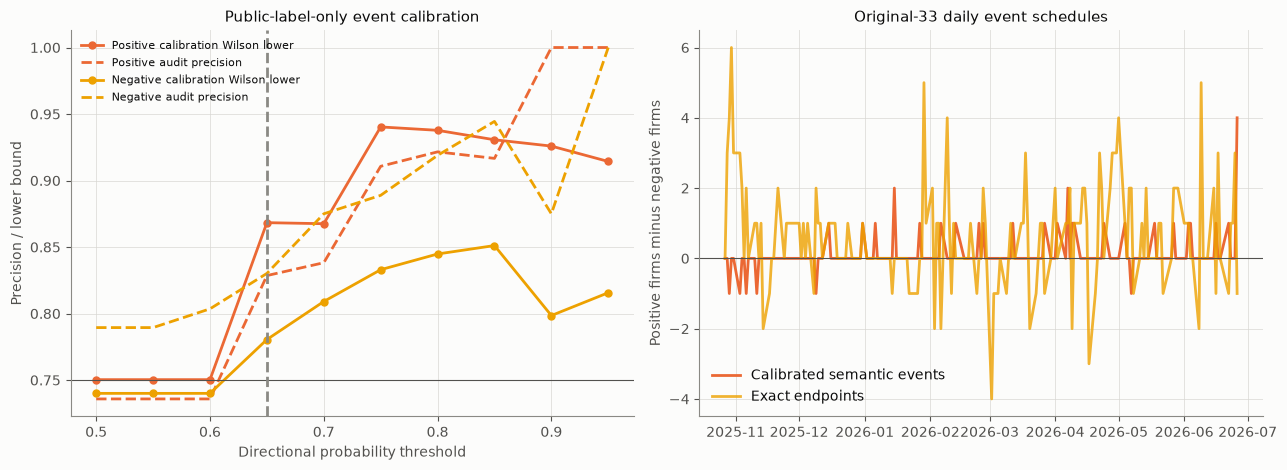

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for direction, colour in (("positive", CATEGORICAL[1]), ("negative", CATEGORICAL[3])):
    axes[0].plot(
        calibration_table["threshold"],
        calibration_table[f"calibration_{direction}_wilson_low"],
        marker="o",
        color=colour,
        label=f"{direction.title()} calibration Wilson lower",
    )
    axes[0].plot(
        calibration_table["threshold"],
        calibration_table[f"audit_{direction}_precision"],
        linestyle="--",
        color=colour,
        label=f"{direction.title()} audit precision",
    )
axes[0].axhline(CALIBRATION_WILSON_FLOOR, color=INK["reference"], linewidth=0.8)
axes[0].axvline(selected_threshold, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Directional probability threshold")
axes[0].set_ylabel("Precision / lower bound")
axes[0].set_title("Public-label-only event calibration")
axes[0].legend(loc="best", fontsize=8)

schedule_plot = semantic_target_audit[["session_date", "positive_names", "negative_names"]].copy()
schedule_plot["net_event_count"] = (
    schedule_plot["positive_names"] - schedule_plot["negative_names"]
)
endpoint_plot = endpoint_target_audit[["session_date", "positive_names", "negative_names"]].copy()
endpoint_plot["net_event_count"] = endpoint_plot["positive_names"] - endpoint_plot["negative_names"]
axes[1].plot(
    schedule_plot["session_date"],
    schedule_plot["net_event_count"],
    color=CATEGORICAL[1],
    label="Calibrated semantic events",
)
axes[1].plot(
    endpoint_plot["session_date"],
    endpoint_plot["net_event_count"],
    color=CATEGORICAL[3],
    alpha=0.8,
    label="Exact endpoints",
)
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_ylabel("Positive firms minus negative firms")
axes[1].set_title("Original-33 daily event schedules")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "public_calibration_and_lseg_schedule.png", dpi=170, bbox_inches="tight")
plt.show()

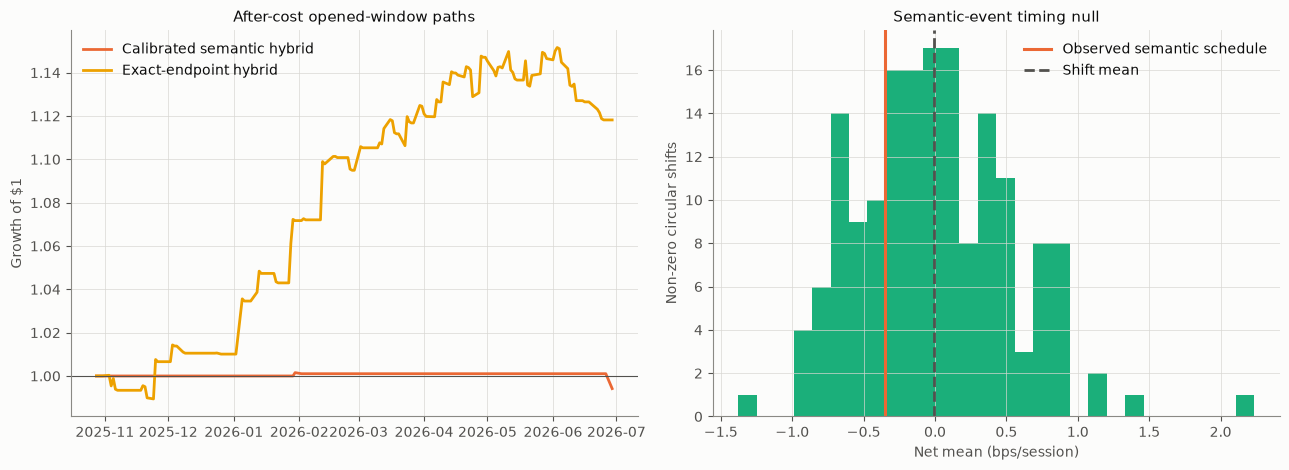

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    semantic_daily["return_end_date"],
    (1.0 + semantic_daily["net_return"]).cumprod(),
    color=CATEGORICAL[1],
    label="Calibrated semantic hybrid",
)
axes[0].plot(
    endpoint_daily["return_end_date"],
    (1.0 + endpoint_daily["net_return"]).cumprod(),
    color=CATEGORICAL[3],
    label="Exact-endpoint hybrid",
)
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("After-cost opened-window paths")
axes[0].legend(loc="best")
axes[1].hist(shift_null["mean_net"] * 10_000, bins=28, color=CATEGORICAL[2])
axes[1].axvline(
    observed["mean_net"] * 10_000,
    color=CATEGORICAL[1],
    linewidth=2.2,
    label="Observed semantic schedule",
)
axes[1].axvline(
    shift_null["mean_net"].mean() * 10_000,
    color=INK["reference"],
    linestyle="--",
    label="Shift mean",
)
axes[1].set_xlabel("Net mean (bps/session)")
axes[1].set_ylabel("Non-zero circular shifts")
axes[1].set_title("Semantic-event timing null")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "strategy_paths_and_timing_null.png", dpi=170, bbox_inches="tight")
plt.show()

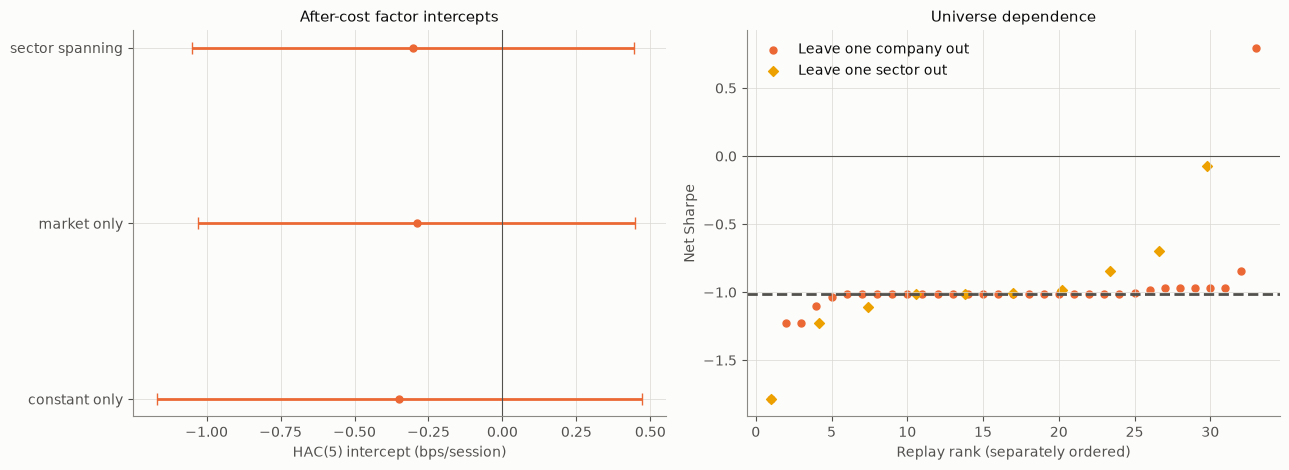

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
models = factor_models.set_index("model").loc[list(model_specs)]
y = np.arange(len(models))
axes[0].errorbar(
    models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            models["alpha_bps_session"] - models["alpha_ci_low_bps_session"],
            models["alpha_ci_high_bps_session"] - models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_yticks(y, [name.replace("_", " ") for name in models.index])
axes[0].set_xlabel("HAC(5) intercept (bps/session)")
axes[0].set_title("After-cost factor intercepts")
axes[1].scatter(
    np.arange(1, len(company_loo) + 1),
    company_loo["sharpe_net"],
    color=CATEGORICAL[1],
    label="Leave one company out",
)
axes[1].scatter(
    np.linspace(1, len(company_loo), len(sector_loo)),
    sector_loo["sharpe_net"],
    color=CATEGORICAL[3],
    marker="D",
    label="Leave one sector out",
)
axes[1].axhline(observed["sharpe_net"], color=INK["reference"], linestyle="--")
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Replay rank (separately ordered)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Universe dependence")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_alpha_and_dependence.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [10]:
calibration_table.to_csv(OUTPUT_DIR / "public_calibration_grid.csv", index=False)
calibration_summary.to_csv(OUTPUT_DIR / "public_calibration_summary.csv", index=False)
schedule_comparison.to_csv(OUTPUT_DIR / "schedule_comparison.csv", index=False)
semantic_target_audit.to_csv(OUTPUT_DIR / "semantic_target_audit.csv", index=False)
semantic_result.to_csv(OUTPUT_DIR / "semantic_strategy_result.csv", index=False)
cash_inference.to_csv(OUTPUT_DIR / "cash_inference.csv", index=False)
endpoint_comparison.to_csv(OUTPUT_DIR / "endpoint_comparison.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal.csv", index=False)
shift_null.to_csv(OUTPUT_DIR / "circular_shift_null.csv", index=False)
timing_inference.to_csv(OUTPUT_DIR / "timing_inference.csv", index=False)
factor_panel.to_csv(OUTPUT_DIR / "factor_panel.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
semantic_daily.to_parquet(OUTPUT_DIR / "semantic_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

notebook36_manifest = json.loads(NOTEBOOK36_MANIFEST.read_text())
manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_PUBLIC_CALIBRATED_SEMANTIC_EVENT_HYBRID",
    "notebook": "38_gemma_calibrated_semantic_event_hybrid.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "public_validation_manifest": str(VALIDATION_MANIFEST.relative_to(REPO_ROOT)),
        "public_validation_responses": str(VALIDATION_RESPONSES.relative_to(REPO_ROOT)),
        "gemma_checkpoint": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PANEL_PATH.relative_to(REPO_ROOT)),
        "notebook36_manifest": str(NOTEBOOK36_MANIFEST.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
    },
    "calibration_specification": {
        "split": "first 700 / last 300 after sentence SHA-256 sort",
        "threshold_grid": list(THRESHOLD_GRID),
        "selection": "lowest threshold with n>=20 and Wilson lower>=0.75 per direction",
        "audit": "n>=10 and empirical precision>=0.75 per direction",
        "selected_threshold": selected_threshold,
    },
    "strategy_specification": {
        "candidate": "public-calibrated Gemma event dates/counts plus FinBERT rank",
        "universe": "immutable original 33",
        "single_name_cap": SINGLE_NAME_CAP,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "cash_inference": f"{REPLICATIONS} five-session circular-block replications",
        "timing_null": "all 166 non-zero circular shifts",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "leave_one_out": "rebuild event schedule and ranks after every exclusion",
        "final_liquidation": True,
    },
    "public_calibration": json.loads(calibration_summary.to_json(orient="records"))[0],
    "schedule_comparison": json.loads(schedule_comparison.to_json(orient="records"))[0],
    "semantic_result": json.loads(semantic_result.to_json(orient="records"))[0],
    "cash_inference": json.loads(cash_inference.to_json(orient="records"))[0],
    "endpoint_comparison": json.loads(endpoint_comparison.to_json(orient="records"))[0],
    "endpoint_reference": notebook36_manifest["result"],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "timing_inference": json.loads(timing_inference.to_json(orient="records"))[0],
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 37 directly motivated replacement of exact endpoints",
        "the confidence threshold is selected on public labels, never on LSEG returns",
        "the same eight-month LSEG return window is already opened repeatedly",
        "public financial-sentiment labels are not return-direction labels",
        "the threshold is calibrated only for Gemma 26B under the pinned prompt and route",
        "the firm-open tie policy abstains when opposing semantic events coexist",
        "the internal sector factors are contemporaneous portfolio benchmarks",
        "circular shifts assume approximate stationarity and wrap endpoints",
        "even a passing gate would require genuinely new dates or companies",
        "human validation of the full LSEG labels remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_PUBLIC_CALIBRATED_SEMANTIC_EVENT_HYBRID",
  "notebook": "38_gemma_calibrated_semantic_event_hybrid.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260812,
  "input": {
    "public_validation_manifest": "final_experiments/outputs/12_lseg_44_labelling/openrouter_gemma4_validation/manifest.json",
    "public_validation_responses": "final_experiments/outputs/12_lseg_44_labelling/openrouter_gemma4_validation/responses.jsonl",
    "gemma_checkpoint": "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "notebook36_manifest": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "licensed_headline_text_loaded": false
  },
  "calibration_specification": {
  

## Decision

**NO-GO for binary semantic collision-abstention.** The return-independent
public calibration selects 0.65. On the held-out 300-label audit, directional
precision is 82.9% positive and 83.0% negative, so the label-quality gate
passes. That semantic success does not create a usable firm-open schedule:
5,472 / 5,511 original-33 firm-opens with at least one selected direction
contain both positive and negative selected headlines (99.29%). The frozen
tie-abstention rule therefore leaves only two active sessions, versus 70 for
the exact-endpoint reference, with no eligible-session overlap.

Performance is correspondingly uninformative and negative: gross/net Sharpe
-0.755/-1.013, net return -0.58%, cash-block mean -0.348 bps per session
(95% interval [-1.233, 0.188], p=0.577), and break-even -19.02 bps per side.
It underperforms the Notebook 36 endpoint candidate by 7.15 bps per session
(paired block 95% interval [-13.93, -1.05], p=0.030). The second half is
negative, circular-shift timing p=0.743, sector-spanning alpha -0.302 bps per
session (95% interval [-1.049, 0.445], p=0.428), and the dependence checks
fail. Every return gate is therefore false.

The useful result is structural: independently thresholding every Reuters
headline and then treating opposite high-confidence directions as an exact
tie is too coarse for a high-volume company-day. Any next calibration-aware
rule should retain continuous confidence or margin to resolve the firm-open
direction, with that construction frozen before another opened-window read.